In [68]:
import pandas as pd
import numpy as np
from sklearn import datasets
from sklearn.model_selection import train_test_split
from sklearn import linear_model
from sklearn.metrics import mean_squared_error,r2_score
import seaborn as sns
import matplotlib.pyplot as plt

In [69]:
california_housing = datasets.fetch_california_housing(as_frame=True)

In [70]:
california_housing=california_housing.frame

In [71]:
california_housing.isnull().sum()

MedInc         0
HouseAge       0
AveRooms       0
AveBedrms      0
Population     0
AveOccup       0
Latitude       0
Longitude      0
MedHouseVal    0
dtype: int64

In [72]:
california_housing.columns=california_housing.columns.str.lower()

In [73]:
california_housing.columns

Index(['medinc', 'houseage', 'averooms', 'avebedrms', 'population', 'aveoccup',
       'latitude', 'longitude', 'medhouseval'],
      dtype='object')

In [74]:
Y=california_housing.medhouseval
Y

0        4.526
1        3.585
2        3.521
3        3.413
4        3.422
         ...  
20635    0.781
20636    0.771
20637    0.923
20638    0.847
20639    0.894
Name: medhouseval, Length: 20640, dtype: float64

In [75]:
X=california_housing.drop(['medhouseval'],axis=1)
X

,medinc,houseage,averooms,avebedrms,population,aveoccup,latitude,longitude
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25
...,...,...,...,...,...,...,...,...
20635,1.5603,25.0,5.045455,1.133333,845.0,2.560606,39.48,-121.09
20636,2.5568,18.0,6.114035,1.315789,356.0,3.122807,39.49,-121.21
20637,1.7000,17.0,5.205543,1.120092,1007.0,2.325635,39.43,-121.22
20638,1.8672,18.0,5.329513,1.171920,741.0,2.123209,39.43,-121.32


In [76]:
#Data split perform 80/20 data split
X_train,X_test,Y_train,Y_test=train_test_split(X,Y,test_size=0.2,random_state=42)

In [78]:
X_train = X_train.reset_index(drop=True)
X_test  = X_test.reset_index(drop=True)
Y_train = Y_train.reset_index(drop=True)
Y_test  = Y_test.reset_index(drop=True)

In [80]:
X_train.shape,Y_train.shape

((16512, 8), (16512,))

In [81]:
X_test.shape,Y_test.shape

((4128, 8), (4128,))

In [82]:
#Build Linear Regression Model
#Defines the regression model
model=linear_model.LinearRegression()

In [83]:
#Build Training Model
model.fit(X_train,Y_train)

LinearRegression()

In [84]:
Y_pred=model.predict(X_test)

In [85]:
#Prediction result
Coefficients=model.coef_
Intercept=model.intercept_
msqr=mean_squared_error(Y_test,Y_pred)
Coefficient_of_detemination=r2_score(Y_test,Y_pred)

In [86]:
print('Coefficients', Coefficients)
print('Intercept',Intercept)
print ('msqr',msqr)
print ('Coefficient_of_detemination',Coefficient_of_detemination)

Coefficients [ 4.48674910e-01  9.72425752e-03 -1.23323343e-01  7.83144907e-01
 -2.02962058e-06 -3.52631849e-03 -4.19792487e-01 -4.33708065e-01]
Intercept -37.02327770606436
msqr 0.5558915986952442
Coefficient_of_detemination 0.575787706032451


In [87]:
#String Formatting
r2_score(Y_test,Y_pred)

0.575787706032451

In [88]:
Y_test

0       0.47700
1       0.45800
2       5.00001
3       2.18600
4       2.78000
         ...   
4123    2.63300
4124    2.66800
4125    5.00001
4126    0.72300
4127    1.51500
Name: medhouseval, Length: 4128, dtype: float64

In [89]:
Y_pred

array([0.71912284, 1.76401657, 2.70965883, ..., 4.46877017, 1.18751119,
       2.00940251])

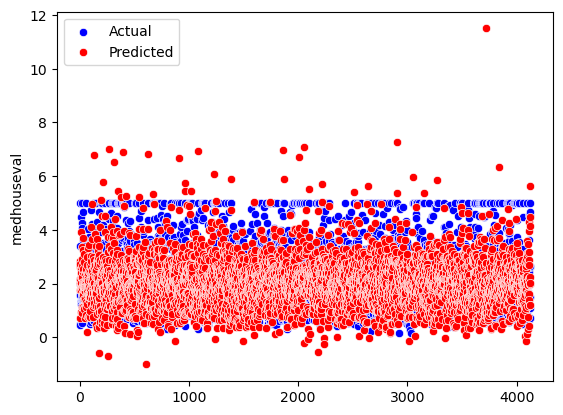

In [90]:
sns.scatterplot(x=range(len(Y_test)), y=Y_test, color='blue', label='Actual')
sns.scatterplot(x=range(len(Y_pred)), y=Y_pred, color='red', label='Predicted')
plt.legend()
plt.show()

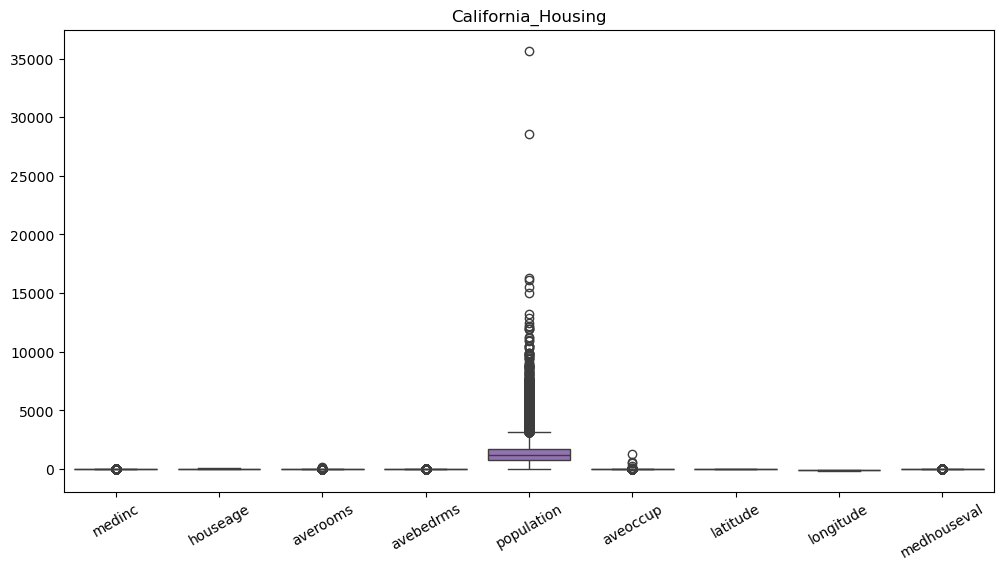

In [100]:
plt.figure(figsize=(12,6))
sns.boxplot(data=california_housing)
plt.xticks(rotation=30)
plt.title("California_Housing")
plt.show()